## Merges all the availble information into a **Final Dataset** to be used for modeling ##

In [1]:
import pandas as pd
import datetime
import missingno
import re

from sklearn.impute import KNNImputer
import sys
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr
import pickle

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")
sys.path.insert(0, "../../../../Mamoth")

from utils import *
from Neural_Network_Module import give_predictions, Dataset


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\Python Virtual Environments\noa_eywa\Lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
utils = importr('utils')
base = importr('base')
dismo = importr('dismo')
utils.chooseCRANmirror(ind=41)

R[write to console]: Warning:
R[write to console]:  failed to download mirrors file (cannot open URL 'https://cran.r-project.org/CRAN_mirrors.csv'); using local file 'C:/Program Files/R/R-4.1.2/doc/CRAN_mirrors.csv'



<rpy2.rinterface_lib.sexp.NULLType object at 0x000001D26AE66190> [0]

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
#NUTS2_EL = 'κεντρικης μακεδονιας'

In [4]:
timeline_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_NUTS3_2024_filled_mean_rain.csv', encoding=enc)
# wnv_file = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Cases_NUTS3_2010-2023.csv', encoding=enc)

In [5]:
timeline_file.head()

,Unnamed: 0,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan
0,0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13689.000000,1.164514,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,1.164514,1.164514,1.164514,1.164514
1,1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,11.846938,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.011452,13.011452,13.011452,13.011452
2,2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,0.714449,3,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901
3,3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13834.000000,0.000000,4,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901
4,4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.000000,13678.000000,0.250432,5,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.976333,13.976333,13.976333,13.976333


In [6]:
try:
    timeline_file.drop(columns=['Unnamed: 0'], inplace=True)
except:
    pass

In [7]:
timeline_file.shape

(106182, 37)

In [8]:
# wnv_file.head()

In [9]:
# wnv_file.shape

In [10]:
timeline_file['lst'] = (timeline_file['lst_day'] + timeline_file['lst_night']) / 2
timeline_file['lst_jan_mean'] = (timeline_file['lst_day_jan_mean'] + timeline_file['lst_night_jan_mean'])/2
timeline_file['lst_feb_mean'] = (timeline_file['lst_day_feb_mean'] + timeline_file['lst_night_feb_mean'])/2
timeline_file['lst_mar_mean'] = (timeline_file['lst_day_mar_mean'] + timeline_file['lst_night_mar_mean'])/2
timeline_file['lst_apr_mean'] = (timeline_file['lst_day_apr_mean'] + timeline_file['lst_night_apr_mean'])/2

In [11]:
timeline_file['dt_placement'] = pd.to_datetime(timeline_file['dt_placement'])
timeline_file['day'] = timeline_file['dt_placement'].apply(lambda x : x.day)
timeline_file['month'] = timeline_file['dt_placement'].apply(lambda x : x.month)
timeline_file['year'] = timeline_file['dt_placement'].apply(lambda x : x.year)
timeline_file['week'] = timeline_file.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

timeline_file = encode_cyclical(timeline_file, 'day', 31)
timeline_file = encode_cyclical(timeline_file, 'month', 12)
timeline_file = encode_cyclical(timeline_file, 'week', 53)

In [12]:
timeline_file.rename(columns={"lst_day_jan_mean": "lst_jan_day_mean",
                        "lst_day_feb_mean": "lst_feb_day_mean",
                        "lst_day_mar_mean": "lst_mar_day_mean",
                        "lst_day_apr_mean": "lst_apr_day_mean",
                        "lst_night_jan_mean": "lst_jan_night_mean",
                        "lst_night_feb_mean": "lst_feb_night_mean",
                        "lst_night_mar_mean": "lst_mar_night_mean",
                        "lst_night_apr_mean": "lst_apr_night_mean"}, inplace=True)

### Add mosquito predictions from trained model

In [13]:
# dataset_list = []
# groups = timeline_file.groupby(['x', 'y', 'year'])

# for group, data in groups:
#     temp_df = data.copy()
#     temp_df.reset_index(drop=True, inplace=True)
#     temp_df['acc_rainfall_1week'] = temp_df['rainfall'].rolling(window=7, min_periods=0).sum()
#     temp_df['acc_rainfall_2week'] = temp_df['rainfall'].rolling(window=14, min_periods=0).sum()
#     temp_df['acc_rainfall_month'] = temp_df['rainfall'].rolling(window=30, min_periods=0).sum()
#     temp_df['acc_rainfall_jan'] = temp_df['dt_placement'].apply(lambda x: temp_df.loc[temp_df['dt_placement'] <= x, 'rainfall'].sum())
#     dataset_list.append(temp_df)

# dataset = pd.concat(dataset_list, ignore_index=True)
# dataset.reset_index(drop=True, inplace=True)

In [14]:
dataset = timeline_file.copy()

In [15]:
dataset.dtypes

NUTS2_ID                      object
NUTS2_NAME                    object
NUTS3_ID                      object
NUTS3_NAME                    object
x                            float64
y                            float64
dt_placement          datetime64[ns]
year                           int64
month                          int64
ndvi                         float64
ndmi                         float64
ndwi                         float64
ndbi                         float64
ndvi_mean                    float64
ndmi_mean                    float64
ndwi_mean                    float64
ndbi_mean                    float64
ndvi_std                     float64
ndmi_std                     float64
ndwi_std                     float64
ndbi_std                     float64
lst_day                      float64
lst_night                    float64
rainfall                     float64
day                            int64
lst_jan_day_mean             float64
lst_jan_night_mean           float64
l

In [16]:
model = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'rb'))
imputer = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'rb'))
scaler = pickle.load(open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'rb'))

In [17]:
mamoth_columns = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

In [18]:
dataset_mamoth = dataset_mamoth_preparation(dataset, mamoth_columns)

In [19]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [20]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<Axes: >

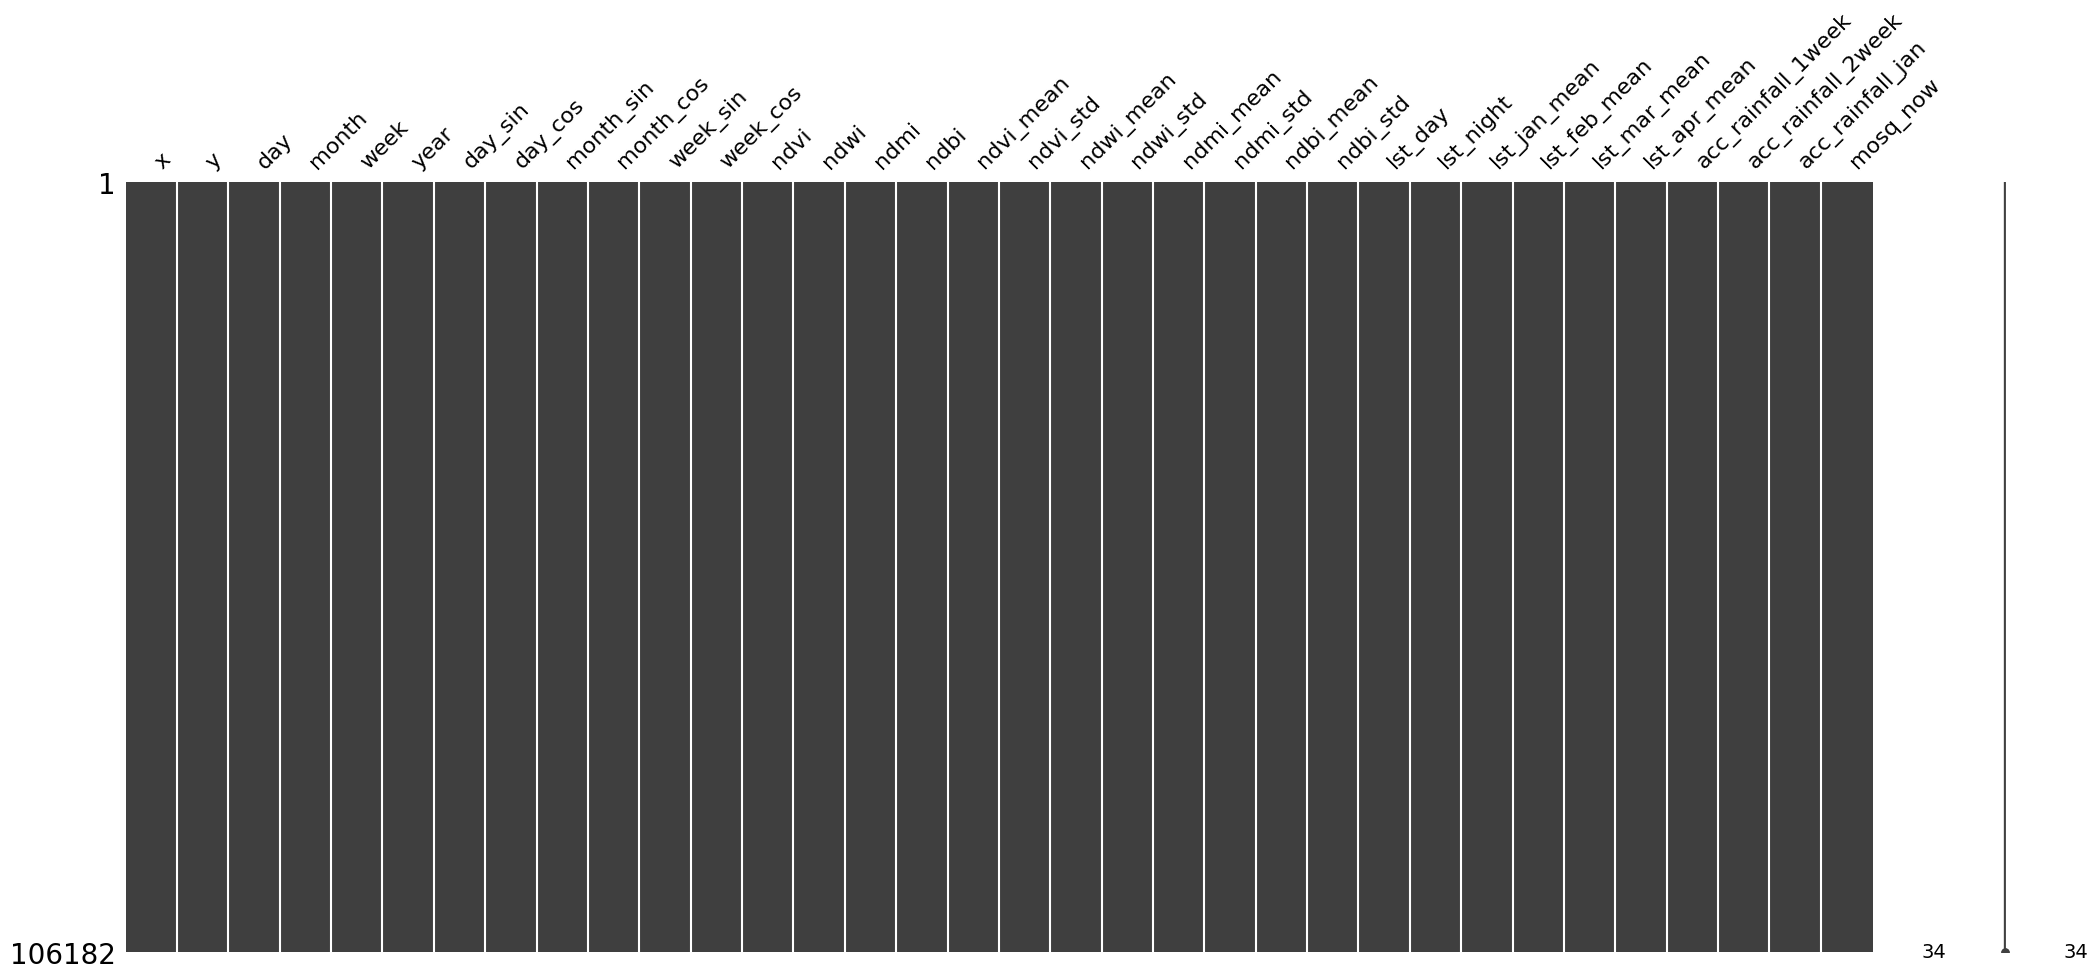

In [21]:
missingno.matrix(dataset_mamoth)

In [22]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [23]:
model_type = 'mosquito_regression'
transform_target = True

dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [24]:
predictions = give_predictions(model, dataset_mamoth)

In [25]:
mosqutio_predictions['mosq_pred'] = predictions
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,21.190210,39.655160,2024-01-01,14
1,21.190210,39.655160,2024-01-02,14
2,21.190210,39.655160,2024-01-03,13
3,21.190210,39.655160,2024-01-04,9
4,21.190210,39.655160,2024-01-05,11
...,...,...,...,...
106177,23.300860,39.203310,2024-05-28,1
106178,23.300860,39.203310,2024-05-29,1
106179,23.300860,39.203310,2024-05-30,1
106180,23.300860,39.203310,2024-05-31,1


<Axes: >

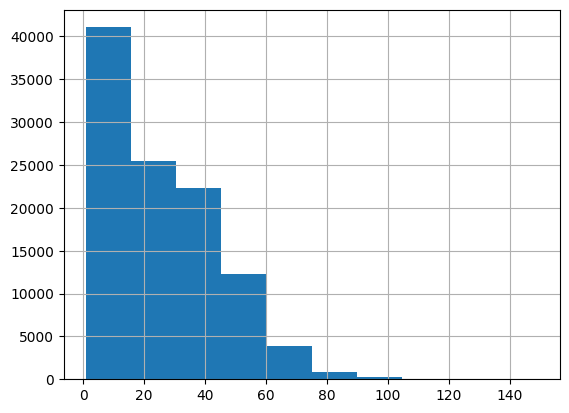

In [26]:
mosqutio_predictions.mosq_pred.hist()

In [27]:
mosqutio_predictions.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2024.csv", encoding = enc, index = False)

# mosqutio_predictions = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_Mosquito_Predictions_2009_2023.csv", encoding = enc)
# mosqutio_predictions['dt_placement'] = pd.to_datetime(mosqutio_predictions['dt_placement'])

#dataset = timeline_file

In [28]:
dataset = pd.merge(dataset, mosqutio_predictions,  how='left', on=['x', 'y', 'dt_placement'])

### Add Geomorphological and Land Cover/Use

In [29]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13689.000000,1.164514,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,1.164514,1.164514,1.164514,1.164514,13751.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,14
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,11.846938,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.011452,13.011452,13.011452,13.011452,13763.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,14
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,0.714449,3,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901,13763.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,13
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13834.000000,0.000000,4,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901,13824.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,9
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.000000,13678.000000,0.250432,5,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.976333,13.976333,13.976333,13.976333,13766.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106177,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2024-05-28,2024,5,0.663965,0.387936,-0.536115,-0.387936,0.661833,0.376551,-0.533285,-0.376551,0.026053,0.034413,0.012817,0.034413,14887.000000,14463.000000,0.000000,28,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804,1.863328,87.631845,141.480840,795.369984,14675.000000,14050.005820,14132.217028,14236.917027,14529.715670,22,-0.571268,0.820763,0.500000,-0.866025,0.508531,-0.861044,1
106178,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",23.300860,39.203310,2024-05-29,2024,5,0.663965,0.387936,-0.536115,-0.387936,0.661833,0.376551,-0.533285,-0.376551,0.026053,0.034413,0.012817,0.034413,14887.000000,14463.000000,0.000000,29,14164.182907,13935.828733,14288.

In [30]:
dataset_locations = dataset[['x', 'y']].drop_duplicates(keep='first')
dataset_locations.reset_index(drop = True, inplace = True)

In [31]:
dataset_locations_per_year = dataset[['x', 'y', 'year']].drop_duplicates(keep='first')
dataset_locations_per_year.reset_index(drop = True, inplace = True)

In [32]:
dataset_locations

,x,y
0,21.190210,39.655160
1,21.190210,39.691090
2,21.236460,39.547360
3,21.236460,39.583290
4,21.236460,39.619230
...,...,...
689,23.254640,39.167380
690,23.254640,39.203310
691,23.254640,39.239250
692,23.254640,39.275180


In [33]:
dataset_locations_per_year

,x,y,year
0,21.190210,39.655160,2024
1,21.190210,39.691090,2024
2,21.236460,39.547360,2024
3,21.236460,39.583290,2024
4,21.236460,39.619230,2024
...,...,...,...
689,23.254640,39.167380,2024
690,23.254640,39.203310,2024
691,23.254640,39.239250,2024
692,23.254640,39.275180,2024


In [34]:
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [35]:
distances, indicies = calculate_nearest_topological(dataset_locations, geomorphological)
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 4.288279034553442e-06
Max distance: 0.00045796332980419137


In [36]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

for index in indicies:
    df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

C:\Users\dimit\AppData\Local\Temp\ipykernel_20484\180837051.py:4: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_geo = pd.concat([df_geo, geomorphological.iloc[[index]]], ignore_index=True)


In [37]:
dataset_geo = pd.concat([dataset_locations, df_geo], axis=1, join = 'outer')
dataset_geo

,x,y,station_id,x_string,y_string,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190210,39.655160,NaN,21.19021g,39.65516g,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780
1,21.190210,39.691090,NaN,21.19021g,39.69109g,23160.169384,346.751574,12,89.441101,1312.022269,166.357352,0.000000,19.208773
2,21.236460,39.547360,NaN,21.23646g,39.54736g,29712.344392,1560.079774,33,301.668176,1642.246643,185.243714,0.000000,1.000000
3,21.236460,39.583290,NaN,21.23646g,39.58329g,28296.253996,73.899784,28,118.019612,1293.667865,180.709172,0.000000,36.806189
4,21.236460,39.619230,NaN,21.23646g,39.61923g,27371.455115,1028.557413,35,67.261475,1299.837739,133.863435,0.000000,1.017342
...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,23.254640,39.167380,NaN,23.25464g,39.16738g,2927.992588,6164.324626,20,150.944226,299.161539,186.676237,0.000000,1.092159
690,23.254640,39.203310,NaN,23.25464g,39.20331g,3538.764441,2412.291850,12,263.973650,298.414731,170.190030,0.000000,1.000000
691,23.254640,39.239250,NaN,23.25464g,39.23925g,4268.432276,2089.637888,2,136.716241,303.961164,175.337355,0.000000,2.880792
692,23.254640,39.275180,NaN,23.25464g,39.27518g,2388.893554,678.662812,25,120.826251,234.983542,171.762613,0.000000,7.010646


In [38]:
dataset_geo.drop(columns=['station_id','x_string','y_string'], inplace = True)

In [39]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km         object
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [40]:
dataset_geo['slope_mean_1km'] = pd.to_numeric(dataset_geo['slope_mean_1km'], errors='coerce').astype('int64')

In [41]:
dataset_geo.dtypes

x                     float64
y                     float64
distance_to_coast     float64
distance_to_river     float64
slope_mean_1km          int64
aspect_mean_200m      float64
elevation_mean_1km    float64
hillshade_mean_1km    float64
fs_area_1km           float64
flow_accu_200m        float64
dtype: object

In [42]:
dataset_geo

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,21.190210,39.655160,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780
1,21.190210,39.691090,23160.169384,346.751574,12,89.441101,1312.022269,166.357352,0.000000,19.208773
2,21.236460,39.547360,29712.344392,1560.079774,33,301.668176,1642.246643,185.243714,0.000000,1.000000
3,21.236460,39.583290,28296.253996,73.899784,28,118.019612,1293.667865,180.709172,0.000000,36.806189
4,21.236460,39.619230,27371.455115,1028.557413,35,67.261475,1299.837739,133.863435,0.000000,1.017342
...,...,...,...,...,...,...,...,...,...,...
689,23.254640,39.167380,2927.992588,6164.324626,20,150.944226,299.161539,186.676237,0.000000,1.092159
690,23.254640,39.203310,3538.764441,2412.291850,12,263.973650,298.414731,170.190030,0.000000,1.000000
691,23.254640,39.239250,4268.432276,2089.637888,2,136.716241,303.961164,175.337355,0.000000,2.880792
692,23.254640,39.275180,2388.893554,678.662812,25,120.826251,234.983542,171.762613,0.000000,7.010646


In [43]:
landcover = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Landcover_2001-2022.csv')
landcover.columns = landcover.columns.str.lower()

In [44]:
lc_columns = landcover.columns.tolist()
lc_columns = [x.split('_')[0] for x in lc_columns]

lc_columns
lc_years = set()

for i in range(0, len(lc_columns)):
    try:
        lc_years.add(int(lc_columns[i]))
    except ValueError:
        pass

lc_years = list(lc_years)

In [45]:
dates_ = re.compile(r"[0-9]{4}_[0-9]{2}_[0-9]{2}_")

for year in lc_years:
    frame_name = f'landcover_{year}'
    location_columns = ['x', 'y']
    filtered_columns = [col for col in landcover if col.startswith(f'{year}')]
    columns_to_keep = location_columns + filtered_columns
    locals()[frame_name] = landcover[columns_to_keep].copy()
    locals()[frame_name].insert(2, 'year', int(year))
    locals()[frame_name] = locals()[frame_name].rename(columns=lambda x: re.sub(dates_,'',x))

In [46]:
data_years = dataset_locations_per_year['year'].unique().tolist()

In [47]:
for year in data_years:
    frame_name = f'dataset_unique_points_annual_{year}'
    locals()[frame_name] = dataset_locations_per_year.query(f"year == {year}").copy()
    locals()[frame_name].reset_index(drop=True, inplace = True)

In [48]:
landcover_2024 = landcover_2023 = landcover_2022

In [49]:
for year in data_years:
    data_name = f'dataset_unique_points_annual_{year}'
    lc_name = f'landcover_{year}'
    merged_name = f'dataset_unique_points_annual_part{year}'
    distances, indicies = calculate_nearest_topological(locals()[data_name], locals()[lc_name])
    print(f'Year: {year}\nMin distance: {min(distances)}\nMax distance: {max(distances)}')

    df_lulc = pd.DataFrame()

    for index in indicies:
        df_lulc = pd.concat([df_lulc, locals()[lc_name].iloc[[index]]], ignore_index=True)

    df_lulc.drop(columns=['x', 'y', 'year'], inplace = True)
    df_lulc.reset_index(drop=True, inplace=True)

    locals()[merged_name] = pd.concat([locals()[data_name], df_lulc], axis=1, join = 'outer')

Year: 2024
Min distance: 0.0
Max distance: 0.0


In [50]:
dataset_lulc = pd.DataFrame()

for year in data_years:
    merged_name = f'dataset_unique_points_annual_part{year}'
    dataset_lulc = pd.concat([dataset_lulc, locals()[merged_name]], ignore_index=True)

In [51]:
dataset_lulc

,x,y,year,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,21.190210,39.655160,2024,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
1,21.190210,39.691090,2024,22,75,20,75.000000,20,75,9,9,4,4,4,2,0
2,21.236460,39.547360,2024,31,96,36,92.000000,30,96,12,12,1,6,7,2,0
3,21.236460,39.583290,2024,31,81,30,81.000000,30,81,10,10,1,6,6,2,0
4,21.236460,39.619230,2024,15,95,10,95.000000,10,95,5,5,6,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689,23.254640,39.167380,2024,12,82,10,97.000000,10,97,2,2,5,2,2,2,0
690,23.254640,39.203310,2024,11,90,10,90.000000,10,90,1,1,7,1,1,2,0
691,23.254640,39.239250,2024,11,72,10,70.000000,10,70,1,1,7,1,1,2,0
692,23.254640,39.275180,2024,21,80,20,80.000000,20,80,8,8,4,2,2,2,0


In [52]:
dataset_lulc.dtypes

x                      float64
y                      float64
year                     int64
lc_prop1                 int64
lc_prop1_assessment      int64
lc_prop2                 int64
lc_prop2_assessment    float64
lc_prop3                 int64
lc_prop3_assessment      int64
lc_type1                 int64
lc_type2                 int64
lc_type3                 int64
lc_type4                 int64
lc_type5                 int64
lw                       int64
qc                       int64
dtype: object

In [53]:
dataset = pd.merge(dataset, dataset_geo, on=['x', 'y'], how='left')

In [54]:
dataset = pd.merge(dataset, dataset_lulc, on=['x', 'y', 'year'], how='left')

In [55]:
dataset

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13689.000000,1.164514,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,1.164514,1.164514,1.164514,1.164514,13751.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,14,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,11.846938,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.011452,13.011452,13.011452,13.011452,13763.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,14,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13712.000000,0.714449,3,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901,13763.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.571268,0.820763,0.500000,0.866025,0.118273,0.992981,13,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.000000,13834.000000,0.000000,4,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.725901,13.725901,13.725901,13.725901,13824.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.724793,0.688967,0.500000,0.866025,0.118273,0.992981,9,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.655160,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.000000,13678.000000,0.250432,5,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,13.976333,13.976333,13.976333,13.976333,13766.000000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.848644,0.528964,0.500000,0.866025,0.118273,0.992981,11,22978.427136,1041.055167,20,162.678483,1447.982715,128.364180,0.000000,1.536780,22,80,20,80.000000,20,80,9,9,4,4,4,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [56]:
grouped_by_nuts3 = dataset.groupby(['dt_placement', 'NUTS2_ID',	'NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

In [57]:
grouped_by_nuts3_mods = grouped_by_nuts3.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()

In [58]:
grouped_by_nuts3_mean = grouped_by_nuts3.mean()
grouped_by_nuts3_min = grouped_by_nuts3.min()
grouped_by_nuts3_max = grouped_by_nuts3.max()
grouped_by_nuts3_std = grouped_by_nuts3.std()

In [59]:
grouped_by_nuts3_min.rename(columns={'distance_to_coast': 'distance_to_coast_min', 'distance_to_river': 'distance_to_river_min', 
                                     'slope_mean_1km': 'slope_mean_1km_min', 'aspect_mean_200m': 'aspect_mean_200m_min', 
                                     'elevation_mean_1km': 'elevation_mean_1km_min', 'hillshade_mean_1km': 'hillshade_mean_1km_min',
                                     'fs_area_1km': 'fs_area_1km_min', 'flow_accu_200m': 'flow_accu_200m_min'}, inplace=True)

grouped_by_nuts3_max.rename(columns={'distance_to_coast': 'distance_to_coast_max', 'distance_to_river': 'distance_to_river_max', 
                                     'slope_mean_1km': 'slope_mean_1km_max', 'aspect_mean_200m': 'aspect_mean_200m_max', 
                                     'elevation_mean_1km': 'elevation_mean_1km_max', 'hillshade_mean_1km': 'hillshade_mean_1km_max',
                                     'fs_area_1km': 'fs_area_1km_max', 'flow_accu_200m': 'flow_accu_200m_max'}, inplace=True)

grouped_by_nuts3_std.rename(columns={'distance_to_coast': 'distance_to_coast_std', 'distance_to_river': 'distance_to_river_std', 
                                     'slope_mean_1km': 'slope_mean_1km_std', 'aspect_mean_200m': 'aspect_mean_200m_std', 
                                     'elevation_mean_1km': 'elevation_mean_1km_std', 'hillshade_mean_1km': 'hillshade_mean_1km_std',
                                     'fs_area_1km': 'fs_area_1km_std', 'flow_accu_200m': 'flow_accu_200m_std'}, inplace=True)

In [60]:
grouped_by_nuts3_mods.drop(columns=['index'], inplace = True)

In [61]:
grouped_by_nuts3_mods

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.837780,39.583290,2024,1,-0.471831,-0.177042,-0.407290,-0.819549,-0.385956,-0.136202,-0.477233,-0.670193,0.000000,0.000000,0.000000,0.000000,14221.000000,13710.000000,0.242175,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,0.242175,0.242175,0.242175,0.242175,13993.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,0.000000,10.738235,2,0.000000,85.575241,111.425738,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
1,2024-01-01,EL61,θεσσαλια,EL612,λαρισα,22.302140,39.759360,2024,1,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,14219.000000,13693.000000,0.000000,1,14160.730142,13815.939184,14316.777654,13875.264244,14501.804949,13959.805527,14907.431828,14182.919140,0.000000,0.000000,0.000000,0.000000,13973.500000,13988.334663,14096.020949,14230.805238,14545.175484,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,807.833526,3.470693,2,48.757971,2.749400,139.798569,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
2,2024-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.792460,39.382980,2024,1,-0.392248,-0.143023,-0.506775,-0.746725,-0.392363,-0.075317,-0.475894,-0.735981,0.000000,0.000000,0.000000,0.000000,14322.000000,13977.000000,1.517299,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804,1.517299,1.517299,1.517299,1.517299,14036.000000,14050.005820,14132.217028,14236.917027,14529.715670,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,493.305640,59.481798,2,48.764328,17.278795,132.356349,0.000000,1.000000,31,99,20,99.000000,30,99,12,12,1,1,1,2,0
3,2024-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.837780,39.583290,2024,1,-0.471831,-0.177042,-0.407290,-0.819549,-0.385956,-0.136202,-0.477233,-0.670193,0.000000,0.000000,0.000000,0.000000,14221.000000,13863.000000,0.515066,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,0.757241,0.757241,0.757241,0.757241,14033.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1,0.000000,10.738235,2,0.000000,85.575241,111.425738,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
4,2024-01-02,EL61,θεσσαλια,EL612,λαρισα,22.302140,39.759360,2024,1,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,14219.000000,13858.000000,0.647824,2,14160.730142,13815.939184,14316.777654,13875.264244,14501.804949,13959.805527,14907.431828,14182.919140,0.799109,0.799109,0.799109,0.799109,14071.500000,13988.334663,14096.020949,14230.805238,14545.175484,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1,807.833526,3.470693,2,48.757971,2.749400,139.798569,0.000000,1.000000,31,99,36,99.000000,30,99,12,12,1,6,7,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [62]:
grouped_by_nuts3_min

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,week,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,mosq_pred,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,lc_prop1,lc_prop1_assessment,lc_prop2,lc_prop2_assessment,lc_prop3,lc_prop3_assessment,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,qc
0,2024-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.080230,2024,1,-0.471831,-0.177042,-0.567776,-0.819549,-0.385956,-0.136202,-0.477233,-0.670193,0.000000,0.000000,0.000000,0.000000,13636.000000,13619.000000,0.000000,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,0.000000,0.000000,0.000000,0.000000,13684.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,3,69,3,69.000000,3,69,1,0,0,0,0,1,0
1,2024-01-01,EL61,θεσσαλια,EL612,λαρισα,21.977880,39.184420,2024,1,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,13823.000000,13575.000000,0.000000,1,14160.730142,13815.939184,14316.777654,13875.264244,14501.804949,13959.805527,14907.431828,14182.919140,0.000000,0.000000,0.000000,0.000000,13758.000000,13988.334663,14096.020949,14230.805238,14545.175484,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,11,61,9,61.000000,10,59,1,1,1,1,1,2,0
2,2024-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.561370,39.023650,2024,1,-0.392248,-0.143023,-0.506775,-0.746725,-0.392363,-0.075317,-0.475894,-0.735981,0.000000,0.000000,0.000000,0.000000,13973.000000,13656.000000,0.773785,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804,0.773785,0.773785,0.773785,0.773785,13931.500000,14050.005820,14132.217028,14236.917027,14529.715670,1,0.201299,0.979530,0.500000,0.866025,0.118273,0.992981,1,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,3,68,3,68.000000,3,68,1,0,0,0,0,2,0
3,2024-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.190210,39.080230,2024,1,-0.471831,-0.177042,-0.567776,-0.819549,-0.385956,-0.136202,-0.477233,-0.670193,0.000000,0.000000,0.000000,0.000000,13636.000000,13666.000000,0.458094,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101,0.587174,0.587174,0.587174,0.587174,13733.500000,13932.370968,14036.395847,14177.881163,14502.306289,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,3,69,3,69.000000,3,69,1,0,0,0,0,1,0
4,2024-01-02,EL61,θεσσαλια,EL612,λαρισα,21.977880,39.184420,2024,1,-0.337748,-0.159391,-0.566412,-0.726619,-0.165005,-0.166280,-0.533666,-0.611225,0.005139,0.011602,0.004516,0.011602,13689.000000,13472.000000,0.424833,2,14160.730142,13815.939184,14316.777654,13875.264244,14501.804949,13959.805527,14907.431828,14182.919140,0.540081,0.540081,0.540081,0.540081,13667.000000,13988.334663,14096.020949,14230.805238,14545.175484,1,0.394356,0.918958,0.500000,0.866025,0.118273,0.992981,1,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,11,61,9,61.000000,10,59,1,1,1,1,1,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,.

In [63]:
grouped_by_nuts3_dataset = pd.concat([grouped_by_nuts3_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME']], 
                                     grouped_by_nuts3_mean[['x','y']],
                                     grouped_by_nuts3_mods[['day','month','year','week']],
                                     grouped_by_nuts3_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_nuts3_mean[['lst_day','lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean','lst_night','lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_nuts3_mean[['rainfall','acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan', 'mosq_pred']],
                                     grouped_by_nuts3_mean[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_nuts3_min[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_nuts3_max[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_nuts3_std[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_nuts3_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']]], axis=1)

In [64]:
grouped_by_nuts3_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw
0,2024-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,14110.150943,14069.498986,14221.000651,14423.290830,14831.676478,13796.977987,13795.242950,13851.791043,13932.471495,14172.936101,13953.564465,13932.370968,14036.395847,14177.881163,14502.306289,0.288677,0.288677,0.288677,0.288677,0.288677,14.305031,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2
1,2024-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2024,1,0.384159,0.100436,-0.322718,-0.100436,0.381905,0.096725,-0.321800,-0.096725,0.061465,0.067712,0.057268,0.067712,14212.035842,14160.730142,14316.777654,14501.804949,14907.431828,13799.318996,13815.939184,13875.264244,13959.805527,14182.919140,14005.677419,13988.334663,14096.020949,14230.805238,14545.175484,0.746040,0.746040,0.746040,0.746040,0.746040,13.326165,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2
2,2024-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2024,1,0.389382,0.190171,-0.303394,-0.190171,0.388770,0.189719,-0.307227,-0.189719,0.068483,0.067176,0.066818,0.067176,14224.453608,14164.182907,14288.283327,14442.140007,14802.364536,13927.896907,13935.828733,13976.150729,14031.694047,14257.066804,14076.175258,14050.005820,14132.217028,14236.917027,14529.715670,1.951446,1.951446,1.951446,1.951446,1.951446,2.350515,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2
3,2024-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,14109.798742,14069.498986,14221.000651,14423.290830,14831.676478,13902.298742,13795.242950,13851.791043,13932.471495,14172.936101,14006.048742,13932.370968,14036.395847,14177.881163,14502.306289,2.152301,2.440978,2.440978,2.440978,2.440978,12.54

<Axes: >

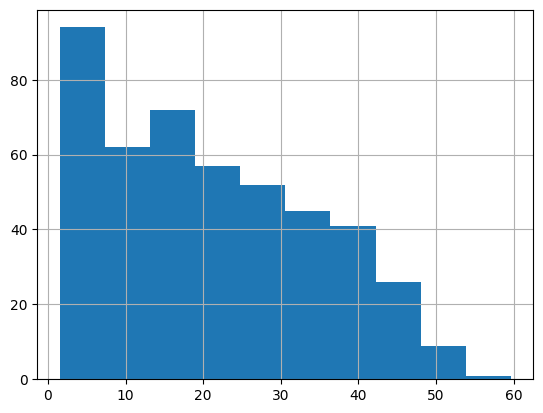

In [65]:
grouped_by_nuts3_dataset.mosq_pred.hist()

In [66]:
grouped_by_nuts3_dataset = convert_temperature(grouped_by_nuts3_dataset)

<Axes: >

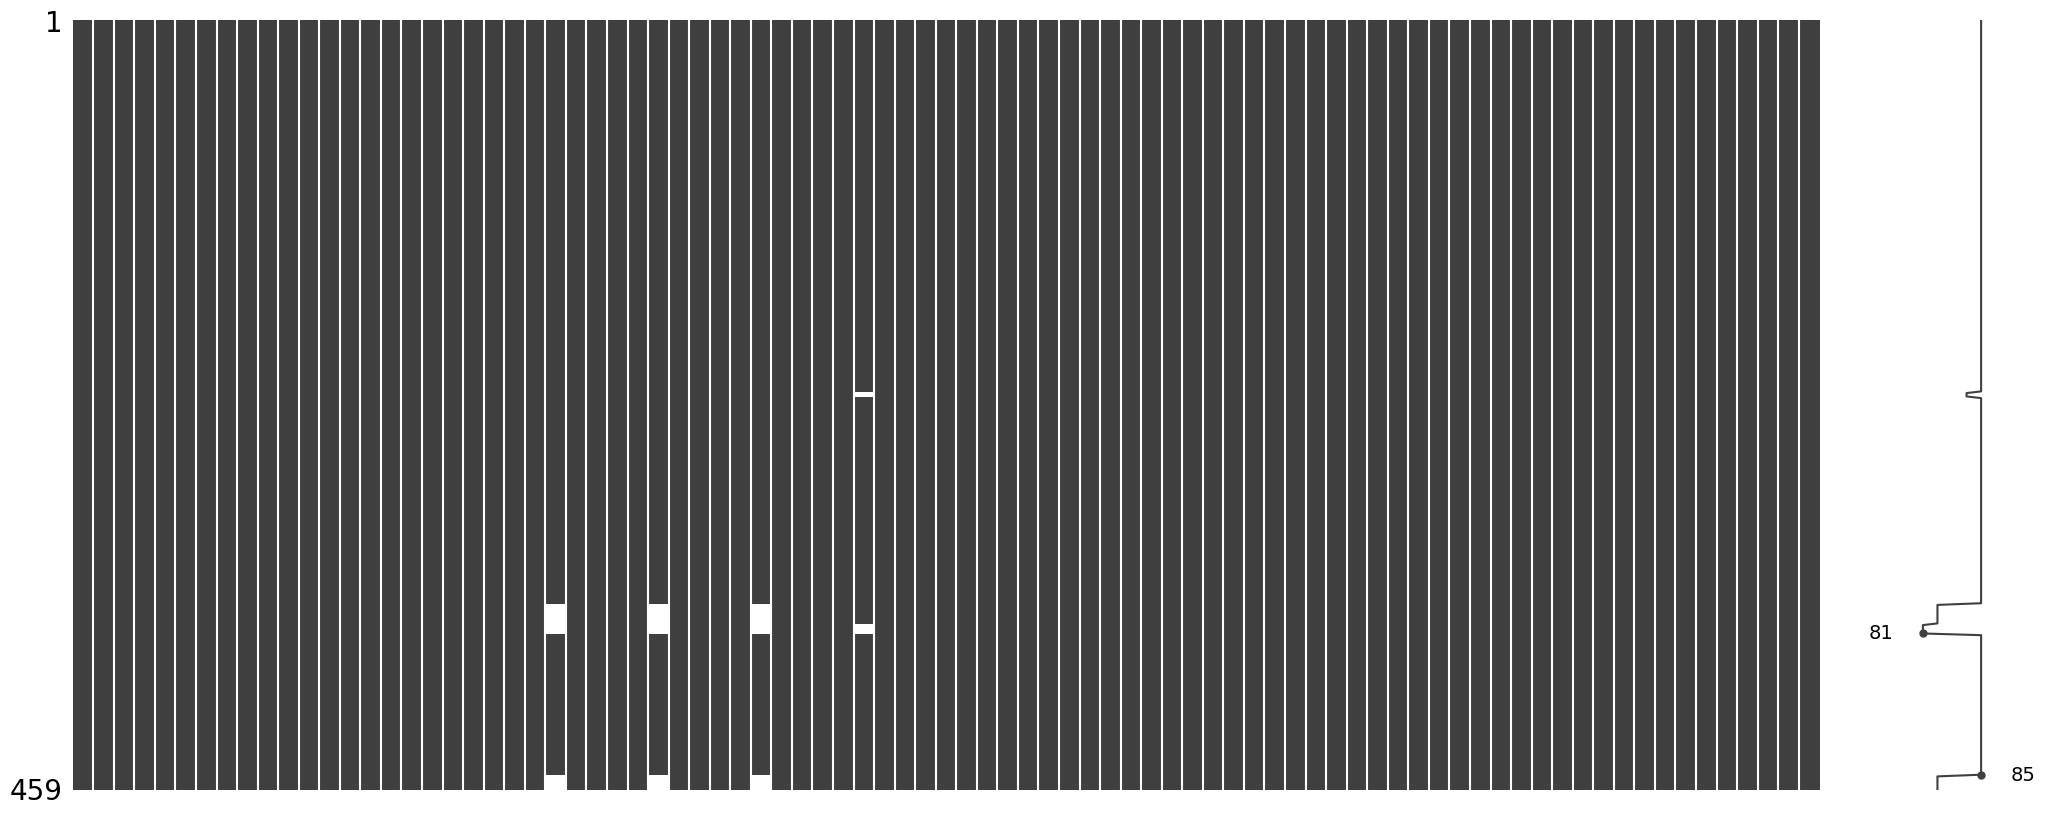

In [67]:
missingno.matrix(grouped_by_nuts3_dataset)

### Add Bio Variables ###

In [68]:
bio_values = []

for region in grouped_by_nuts3_dataset.NUTS3_NAME.unique():
    for year in grouped_by_nuts3_dataset.year.unique():
        for month in grouped_by_nuts3_dataset.month.unique():
            filtered_df = grouped_by_nuts3_dataset.loc[(grouped_by_nuts3_dataset['year'] == year) & (grouped_by_nuts3_dataset['NUTS3_NAME'] == region) & (grouped_by_nuts3_dataset['month'] == month)].copy()
            tmin = min(filtered_df['lst_day'].min(), filtered_df['lst_night'].min())
            tmax = max(filtered_df['lst_day'].max(), filtered_df['lst_night'].max())
            prec = filtered_df['rainfall'].sum()
            bio_values.append({'NUTS3_NAME': region, 
                               'year': year, 
                               'month': month, 
                               'monthly_lst_min': tmin, 
                               'monthly_lst_max': tmax,
                               'monthly_acc_prec': prec})

In [69]:
bio_values_df = pd.DataFrame(bio_values)

In [70]:
bio_values_df

,NUTS3_NAME,year,month,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,"καρδιτσα, τρικαλα",2024,1,-2.440881,13.502390,116.947373
1,"καρδιτσα, τρικαλα",2024,2,-1.664151,14.408302,65.542872
2,"καρδιτσα, τρικαλα",2024,3,2.556981,23.452138,89.383803
3,"καρδιτσα, τρικαλα",2024,4,5.532453,27.998428,103.377999
4,"καρδιτσα, τρικαλα",2024,5,9.732075,27.747421,58.995331
5,"καρδιτσα, τρικαλα",2024,6,NaN,NaN,0.000000
6,λαρισα,2024,1,-2.565914,16.256380,56.684445
7,λαρισα,2024,2,-2.050358,16.007061,70.933979
8,λαρισα,2024,3,2.446129,24.782832,71.034733
9,λαρισα,2024,4,3.860824,30.219462,94.212015


In [71]:
dataset = pd.merge(grouped_by_nuts3_dataset, bio_values_df, on=['NUTS3_NAME', 'year', 'month'], how='left')

In [72]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,9.053019,8.239980,11.270013,15.315817,23.483530,2.789560,2.754859,3.885821,5.499430,10.308722,5.921289,5.497419,7.577917,10.407623,16.896126,0.288677,0.288677,0.288677,0.288677,0.288677,14.305031,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373
1,2024-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2024,1,0.384159,0.100436,-0.322718,-0.100436,0.381905,0.096725,-0.321800,-0.096725,0.061465,0.067712,0.057268,0.067712,11.090717,10.064603,13.185553,16.886099,24.998637,2.836380,3.168784,4.355285,6.046111,10.508383,6.963548,6.616693,8.770419,11.466105,17.753510,0.746040,0.746040,0.746040,0.746040,0.746040,13.326165,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445
2,2024-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2024,1,0.389382,0.190171,-0.303394,-0.190171,0.388770,0.189719,-0.307227,-0.189719,0.068483,0.067176,0.066818,0.067176,11.339072,10.133658,12.615667,15.692800,22.897291,5.407938,5.566575,6.373015,7.483881,11.991336,8.373505,7.850116,9.494341,11.588341,17.444313,1.951446,1.951446,1.951446,1.951446,1.951446,2.350515,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2,-0.191237,15.555567,73.288175
3,2024-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,9.045975,8.239980,11.270013,15.315817,23.483530,4.895975,2.754859,3.885821,5.499430,10.308722,6.970975,5.497419,7.577917,10.407623,16.896126,2.152301,2.440978,2.440978,2.440978,2.440978,12.547170,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743

<Axes: >

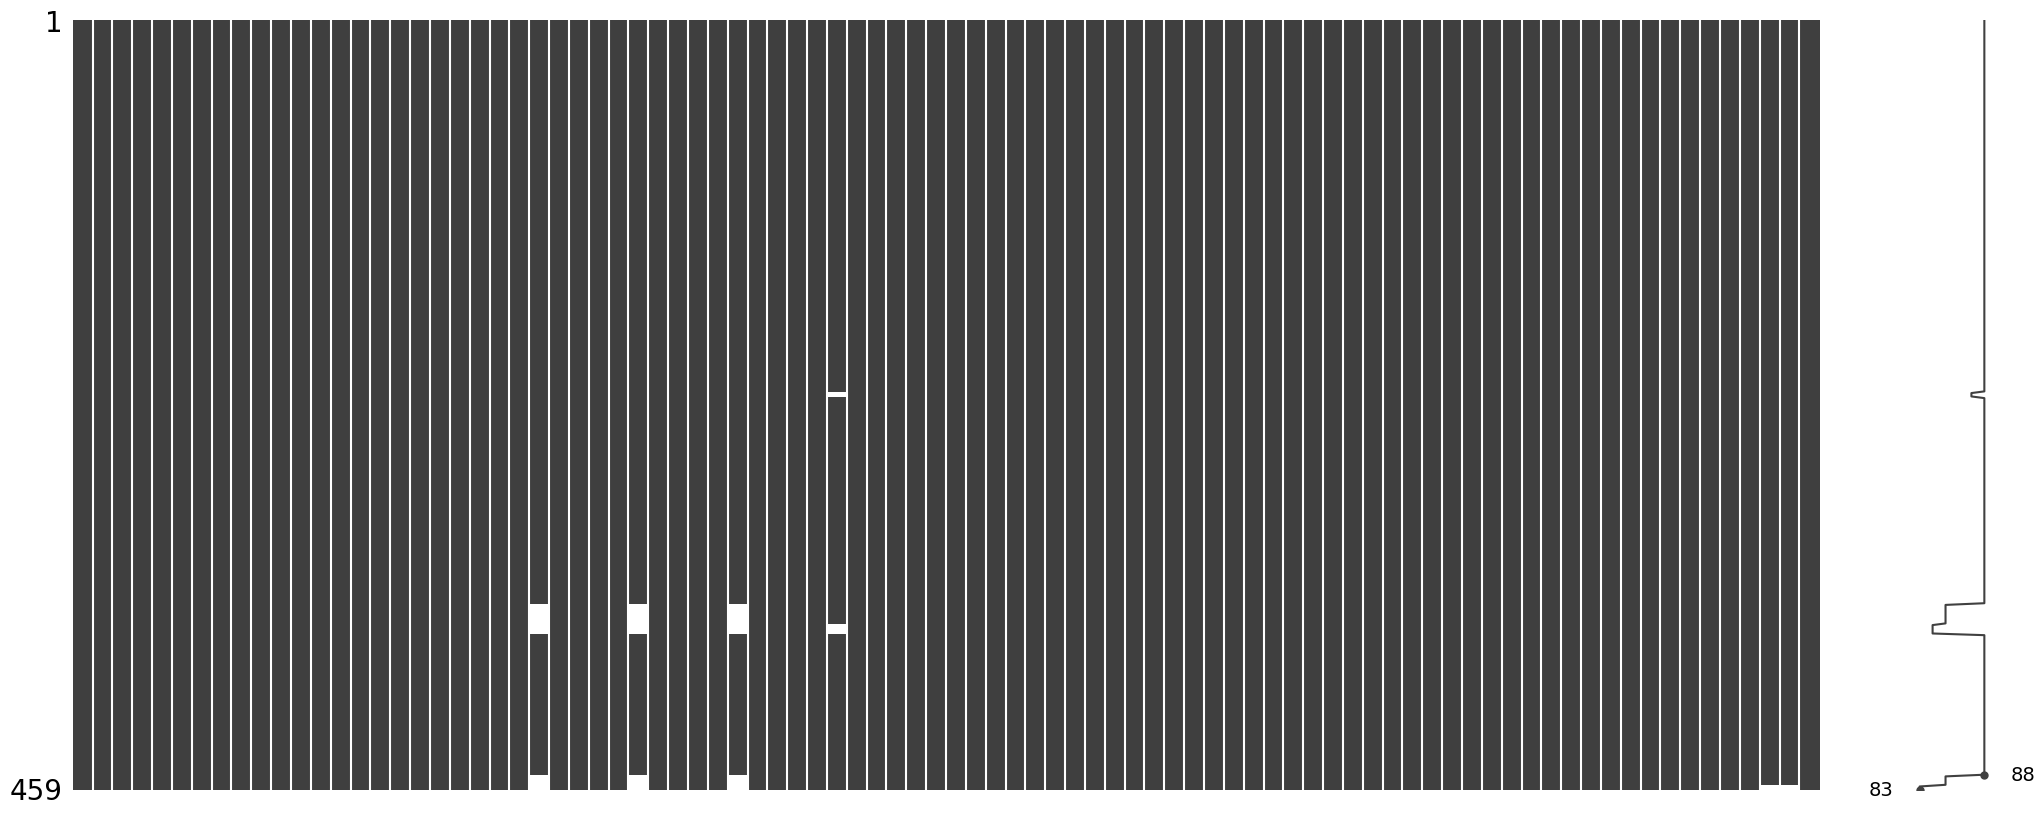

In [73]:
missingno.matrix(dataset)

In [74]:
dataset.rename(columns={"dt_placement": "dt_placement_daily"}, inplace=True)

In [75]:
dataset['date_string'] = dataset['month'].astype(str) + '-' + dataset['year'].astype(str)
dataset['dt_placement'] = pd.to_datetime(dataset['date_string'], format='%m-%Y').dt.to_period('M')
dataset.drop(columns=['date_string'], inplace = True)

In [76]:
dataset

,dt_placement_daily,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,dt_placement
0,2024-01-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,9.053019,8.239980,11.270013,15.315817,23.483530,2.789560,2.754859,3.885821,5.499430,10.308722,5.921289,5.497419,7.577917,10.407623,16.896126,0.288677,0.288677,0.288677,0.288677,0.288677,14.305031,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373,2024-01
1,2024-01-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2024,1,0.384159,0.100436,-0.322718,-0.100436,0.381905,0.096725,-0.321800,-0.096725,0.061465,0.067712,0.057268,0.067712,11.090717,10.064603,13.185553,16.886099,24.998637,2.836380,3.168784,4.355285,6.046111,10.508383,6.963548,6.616693,8.770419,11.466105,17.753510,0.746040,0.746040,0.746040,0.746040,0.746040,13.326165,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,2024-01
2,2024-01-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2024,1,0.389382,0.190171,-0.303394,-0.190171,0.388770,0.189719,-0.307227,-0.189719,0.068483,0.067176,0.066818,0.067176,11.339072,10.133658,12.615667,15.692800,22.897291,5.407938,5.566575,6.373015,7.483881,11.991336,8.373505,7.850116,9.494341,11.588341,17.444313,1.951446,1.951446,1.951446,1.951446,1.951446,2.350515,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2,-0.191237,15.555567,73.288175,2024-01
3,2024-01-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,1,2024,1,0.345358,0.111987,-0.281475,-0.111987,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,9.045975,8.239980,11.270013,15.315817,23.483530,4.895975,2.754859,3.885821,5.499430,10.308722,6.970975,5.497419,7.577917,10.407623,16.896126,2.152301,2.440978,2.440978,2.440978,2.440978,12.547170,27200.472304,1274.356805

In [77]:
grouped_by_month = dataset.drop(columns=['dt_placement_daily']).groupby(['dt_placement', 'NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME'], as_index = False)

grouped_by_month_mods = grouped_by_month.agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index()
grouped_by_month_mean = grouped_by_month.mean()
grouped_by_month_min = grouped_by_month.min()
grouped_by_month_max = grouped_by_month.max()
grouped_by_month_sum = grouped_by_month.sum()
grouped_by_month_last = grouped_by_month.last()

grouped_by_month_mods

,index,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,day,month,year,week,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,1,2024,1,0.308674,0.111987,-0.281475,-0.130971,0.344149,0.105865,-0.281241,-0.106387,0.071385,0.072528,0.076172,0.072666,13.502390,8.239980,11.270013,15.315817,23.483530,-1.159937,2.754859,3.885821,5.499430,10.308722,1.596981,5.497419,7.577917,10.407623,16.896126,0.005425,0.288677,0.288677,0.288677,0.288677,8.512579,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373
1,1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,1,2024,1,0.384159,0.100436,-0.322718,-0.100436,0.381905,0.096725,-0.321800,-0.096725,0.061465,0.067712,0.057268,0.067712,16.256380,10.064603,13.185553,16.886099,24.998637,-1.208136,3.168784,4.355285,6.046111,10.508383,8.874337,6.616693,8.770419,11.466105,17.753510,0.000000,0.746040,32.353285,32.353285,32.353285,8.254480,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445
2,2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,1,2024,1,0.389382,0.190171,-0.303394,-0.190171,0.384398,0.193978,-0.348349,-0.337585,0.063286,0.062690,0.063284,0.062690,10.968969,10.133658,12.615667,15.692800,22.897291,6.791031,5.566575,6.373015,7.483881,11.991336,8.880000,7.850116,9.494341,11.588341,17.444313,0.000000,1.951446,1.951446,69.048980,69.048980,1.721649,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2,-0.191237,15.555567,73.288175
3,3,2024-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2,2024,6,0.362378,0.107043,-0.321167,-0.107043,0.315499,0.085071,-0.350572,-0.172015,0.053179,0.055825,0.051120,0.055825,12.253396,8.239980,11.270013,15.315817,23.483530,3.594088,2.754859,3.885821,5.499430,10.308722,7.899434,5.497419,7.577917,10.407623,16.896126,0.000966,0.381966,2.502230,25.392419,117.071742,16.220126,27200.472304,1274.356805,14.386792,157.112436,592.60688

In [78]:
grouped_by_month_dataset = pd.concat([grouped_by_month_mods[['dt_placement','NUTS2_ID','NUTS2_NAME','NUTS3_ID','NUTS3_NAME', 'x', 'y', 'month', 'year']], 
                                     grouped_by_month_mean[['ndvi','ndmi','ndwi','ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std','ndmi_std','ndwi_std','ndbi_std']],
                                     grouped_by_month_mean[['lst_day','lst_night','lst']].rename(columns={'lst_day': 'lst_day_mean', 'lst_night': 'lst_night_mean', 'lst': 'lst_mean'}),
                                     grouped_by_month_last[['lst_jan_day_mean','lst_feb_day_mean','lst_mar_day_mean','lst_apr_day_mean', 'lst_jan_night_mean','lst_feb_night_mean','lst_mar_night_mean','lst_apr_night_mean','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']],
                                     grouped_by_month_mean[['rainfall']].rename(columns={'rainfall':'rainfall_mean'}),
                                     grouped_by_month_last[['acc_rainfall_1week','acc_rainfall_2week','acc_rainfall_month','acc_rainfall_jan']],
                                     grouped_by_month_sum[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_acc'}),
                                     grouped_by_month_mean[['mosq_pred']].rename(columns={'mosq_pred':'mosq_pred_mean'}),
                                     grouped_by_month_mods[['distance_to_coast','distance_to_river','slope_mean_1km','aspect_mean_200m','elevation_mean_1km','hillshade_mean_1km','fs_area_1km','flow_accu_200m']],
                                     grouped_by_month_mods[['distance_to_coast_min','distance_to_river_min','slope_mean_1km_min','aspect_mean_200m_min','elevation_mean_1km_min','hillshade_mean_1km_min','fs_area_1km_min','flow_accu_200m_min']],
                                     grouped_by_month_mods[['distance_to_coast_max','distance_to_river_max','slope_mean_1km_max','aspect_mean_200m_max','elevation_mean_1km_max','hillshade_mean_1km_max','fs_area_1km_max','flow_accu_200m_max']],
                                     grouped_by_month_mods[['distance_to_coast_std','distance_to_river_std','slope_mean_1km_std','aspect_mean_200m_std','elevation_mean_1km_std','hillshade_mean_1km_std','fs_area_1km_std','flow_accu_200m_std']],
                                     grouped_by_month_mods[['lc_prop1','lc_prop2','lc_prop3','lc_type1','lc_type2','lc_type3','lc_type4','lc_type5','lw']],
                                     grouped_by_month_mods[['monthly_lst_min','monthly_lst_max','monthly_acc_prec']]], axis=1)

In [79]:
grouped_by_month_dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec
0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2024,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,2.754859,5.497419,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445
2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2024,0.397821,0.237224,-0.313479,-0.237224,0.400174,0.234837,-0.318410,-0.234837,0.068333,0.069368,0.065917,0.069368,10.133658,5.566575,7.850116,10.133658,12.615667,15.692800,22.897291,5.566575,6.373015,7.483881,11.991336,7.850116,9.494341,11.588341,17.444313,2.364135,4.172262,18.432752,71.336729,73.288175,87.030928,2.807449,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2,-0.191237,15.555567,73.288175
3,2024-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,2024,0.369467,0.109724,-0.328050,-0.109724,0.360121,0.108430,-0.321235,-0.108430,0.062147,0.067764,0.057353,0.067764,11.270013,3.885821,7.577917,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,2.260099,38.804018,40.941763,65.578676,182.490245,778.399371,26.841358,27200

In [80]:
# wnv_file.head(5)

In [81]:
grouped_by_month_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 87 columns):
 #   Column                  Non-Null Count  Dtype    
---  ------                  --------------  -----    
 0   dt_placement            18 non-null     period[M]
 1   NUTS2_ID                18 non-null     object   
 2   NUTS2_NAME              18 non-null     object   
 3   NUTS3_ID                18 non-null     object   
 4   NUTS3_NAME              18 non-null     object   
 5   x                       18 non-null     float64  
 6   y                       18 non-null     float64  
 7   month                   18 non-null     int64    
 8   year                    18 non-null     int64    
 9   ndvi                    18 non-null     float64  
 10  ndmi                    18 non-null     float64  
 11  ndwi                    18 non-null     float64  
 12  ndbi                    18 non-null     float64  
 13  ndvi_mean               18 non-null     float64  
 14  ndmi_mean   

In [82]:
# wnv_file.info()

In [83]:
# wnv_file['dt_placement'] = pd.to_datetime(wnv_file['dt_placement'], format='%Y-%m').dt.to_period('M')

In [84]:
# wnv_file

In [85]:
# wnv_file['cases'].value_counts()

In [86]:
# wnv_file.cases.sum()

In [87]:
# merged = grouped_by_month_dataset.merge(wnv_file, how='left', on=['dt_placement', 'NUTS3_NAME', 'NUTS2_NAME'] )
merged = grouped_by_month_dataset.copy()

In [88]:
merged['cases'] = 0

In [89]:
merged

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases
0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2024,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,2.754859,5.497419,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373,0
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,0
2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2024,0.397821,0.237224,-0.313479,-0.237224,0.400174,0.234837,-0.318410,-0.234837,0.068333,0.069368,0.065917,0.069368,10.133658,5.566575,7.850116,10.133658,12.615667,15.692800,22.897291,5.566575,6.373015,7.483881,11.991336,7.850116,9.494341,11.588341,17.444313,2.364135,4.172262,18.432752,71.336729,73.288175,87.030928,2.807449,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0,48.764328,17.278795,132.356349,0.000000,1.000000,20896.711972,6164.324626,33,321.331289,1245.602160,216.252716,0.016028,607.657522,4909.905403,1112.256544,7.702381,62.992476,322.583246,14.381144,0.001717,63.557978,31,20,30,12,12,1,1,1,2,-0.191237,15.555567,73.288175,0
3,2024-02,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,2,2024,0.369467,0.109724,-0.328050,-0.109724,0.360121,0.108430,-0.321235,-0.108430,0.062147,0.067764,0.057353,0.067764,11.270013,3.885821,7.577917,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,2.260099,38.804018,40.941763,65.578676,182.490245,778.399371,26.

In [90]:
merged = fillna(merged,{'cases': 0})

In [91]:
merged['cases'].value_counts()

cases
0    18
Name: count, dtype: int64

In [92]:
merged.cases.sum()

0

In [93]:
merged = merged.astype({'cases': 'int'})

<Axes: >

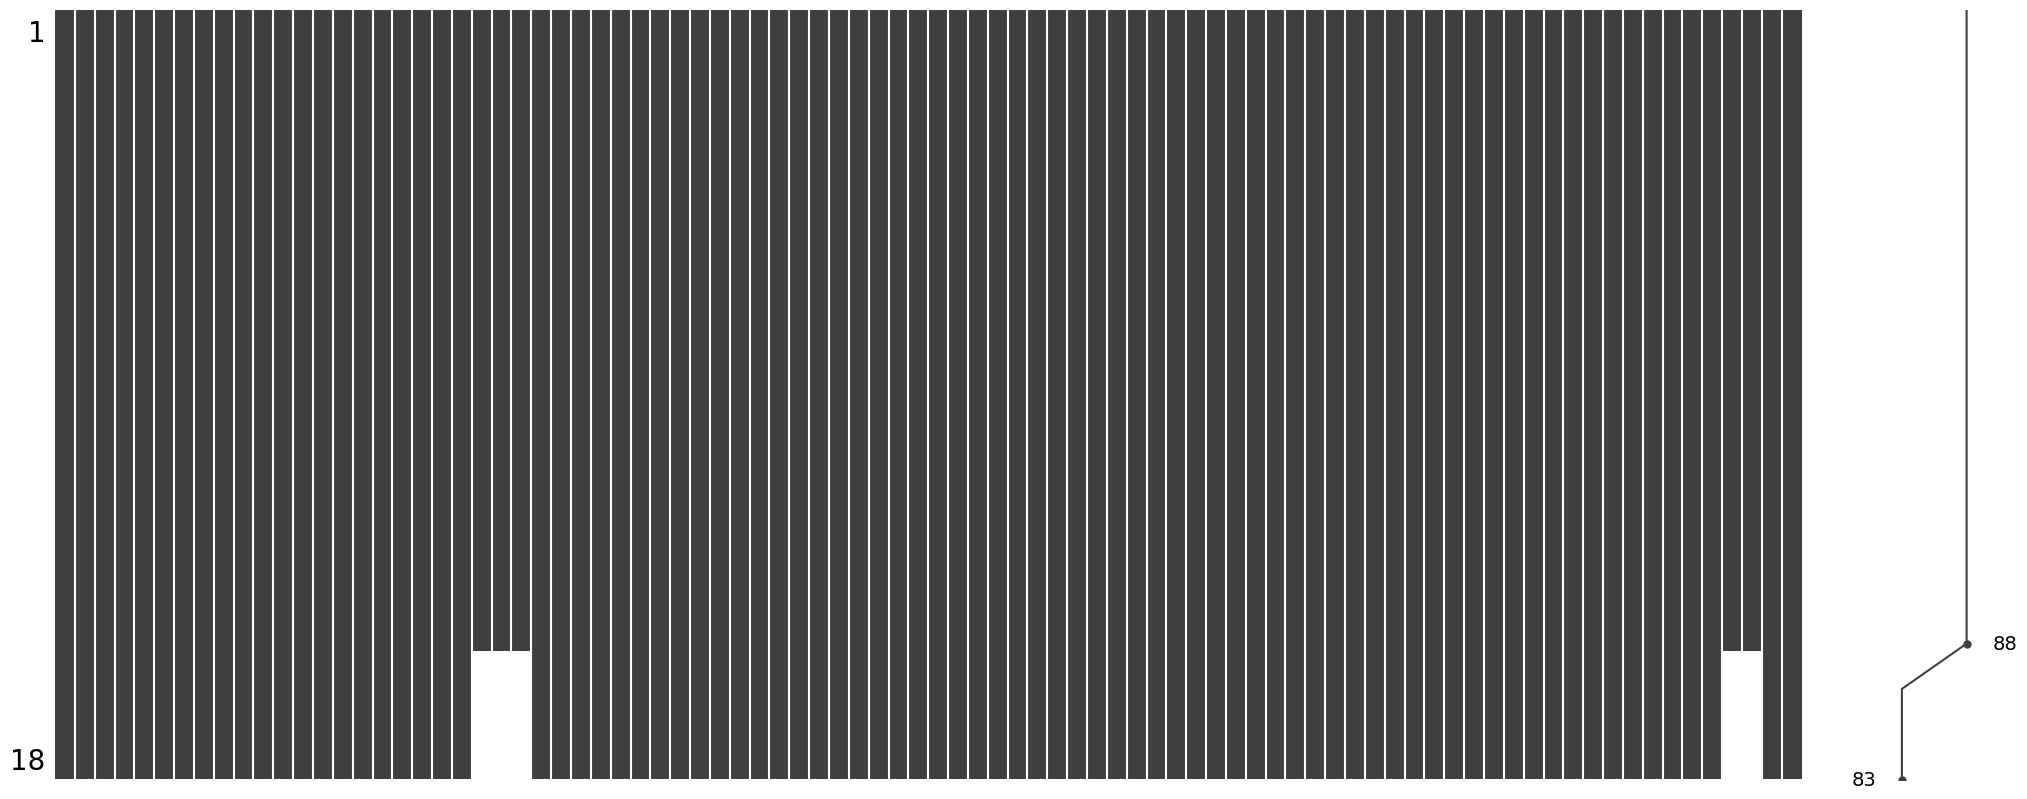

In [94]:
missingno.matrix(merged)

In [95]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'month', 'year', 'monthly_lst_min', 'monthly_lst_max']

temp_df = merged[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['monthly_lst_min', 'monthly_lst_max']

merged[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

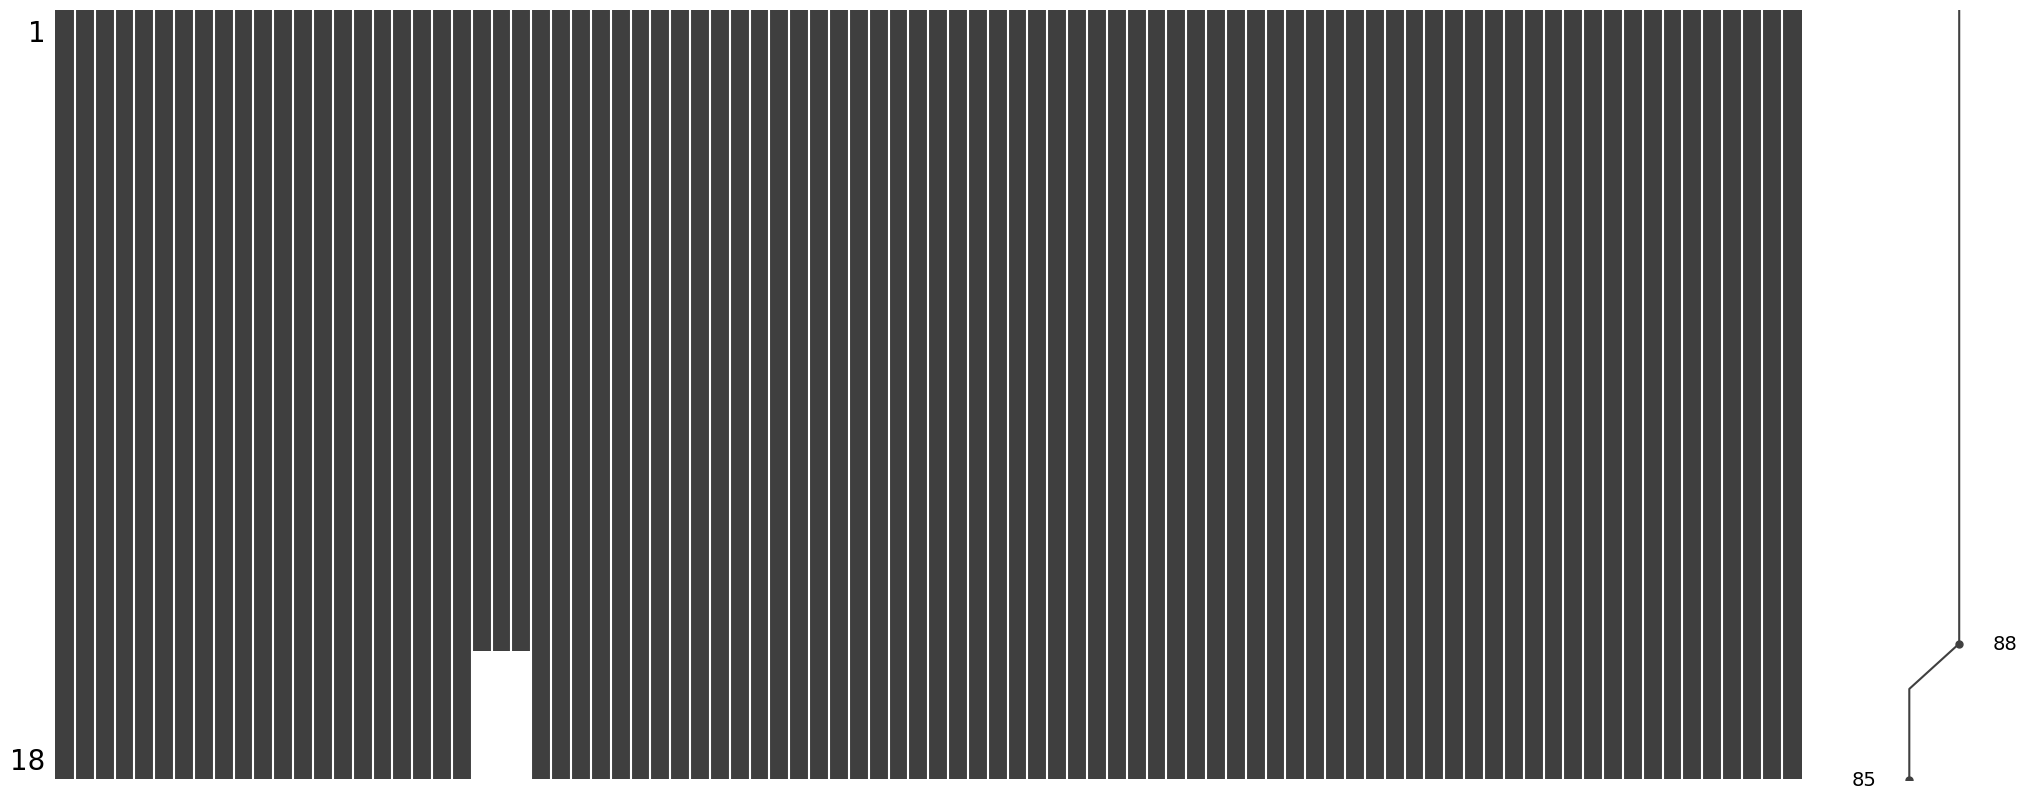

In [96]:
missingno.matrix(merged)

In [97]:
years = merged.year.unique()
years

array([2024], dtype=int64)

In [98]:
nuts3_units = merged.NUTS3_NAME.unique()
nuts3_units

array(['καρδιτσα, τρικαλα', 'λαρισα', 'μαγνησια, σποραδες'], dtype=object)

In [99]:
rows = []
for year in years:
    for region in nuts3_units:
        filtered_df = merged.loc[(merged['year'] == year) & (merged['NUTS3_NAME'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        tmin = robjects.IntVector(filtered_df['monthly_lst_min'].tolist())
        tmax = robjects.IntVector(filtered_df['monthly_lst_max'].tolist())
        prec = robjects.IntVector(filtered_df['monthly_acc_prec'].tolist())

        bio_vars = list(dismo.biovars(prec, tmin, tmax))

        rows.append({'NUTS3_NAME': region, 
                     'year': year, 
                     'bio1': bio_vars[0],
                     'bio2': bio_vars[1],
                     'bio3': bio_vars[2],
                     'bio4': bio_vars[3],
                     'bio5': bio_vars[4],
                     'bio6': bio_vars[5],
                     'bio7': bio_vars[6],
                     'bio8': bio_vars[7],
                     'bio9': bio_vars[8],
                     'bio10': bio_vars[9],
                     'bio11': bio_vars[10],
                     'bio12': bio_vars[11],
                     'bio13': bio_vars[12],
                     'bio14': bio_vars[13],
                     'bio15': bio_vars[14],
                     'bio16': bio_vars[15],
                     'bio17': bio_vars[16],
                     'bio18': bio_vars[17],
                     'bio19': bio_vars[18]})
        
biovars_df = pd.DataFrame(rows)

In [100]:
biovars_df.head(20)

,NUTS3_NAME,year,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,"καρδιτσα, τρικαλα",2024,12.750000,18.833333,60.752688,561.025846,29.000000,-2.000000,31.000000,8.166667,17.333333,17.333333,8.166667,431.000000,116.000000,0.000000,56.991259,270.000000,161.000000,161.000000,270.000000
1,λαρισα,2024,13.666667,21.666667,63.725490,570.672118,32.000000,-2.000000,34.000000,16.666667,10.666667,18.333333,9.000000,382.000000,94.000000,0.000000,53.000119,256.000000,126.000000,185.000000,197.000000
2,"μαγνησια, σποραδες",2024,13.750000,19.166667,66.091954,507.690851,29.000000,0.000000,29.000000,16.333333,11.166667,18.000000,9.500000,574.000000,150.000000,0.000000,55.994734,375.000000,199.000000,279.000000,295.000000


In [101]:
merged = pd.merge(merged, biovars_df,  how='left', on=['NUTS3_NAME', 'year'])

In [102]:
##check if biovars have the same value across all months
merged.loc[(merged['year'] == 2024) & (merged['NUTS3_NAME'] == 'λαρισα')]

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,0,13.666667,21.666667,63.725490,570.672118,32.000000,-2.000000,34.000000,16.666667,10.666667,18.333333,9.000000,382.000000,94.000000,0.000000,53.000119,256.000000,126.000000,185.000000,197.000000
4,2024-02,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,2,2024,0.446857,0.142922,-0.390352,-0.142922,0.437232,0.141379,-0.382327,-0.141379,0.064526,0.073486,0.053984,0.073486,13.185553,4.355285,8.770419,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,2.445999,39.164991,40.828247,70.941883,127.618424,657.222222,22.662835,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.050358,16.007061,70.933979,0,13.666667,21.666667,63.725490,570.672118,32.000000,-2.000000,34.000000,16.666667,10.666667,18.333333,9.000000,382.000000,94.000000,0.000000,53.000119,256.000000,126.000000,185.000000,197.000000
7,2024-03,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,3,2024,0.517852,0.199477,-0.447278,-0.199477,0.506873,0.196243,-0.437523,-0.196243,0.070526,0.078027,0.056327,0.078027,16.886099,6.046111,11.466105,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,2.367824,4.246356,11.195052,31.368887,198.653156,779.630824,25.149381,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577

In [103]:
df_demographics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Demographics_Processed.csv', encoding = enc)

In [104]:
df_demographics

,NUTS3_CODE,YEAR,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [105]:
df_demographics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [106]:
df_demographics

,NUTS3_ID,year,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL
0,EL301,1991,51138.000000,165030.000000,25941.000000,242109.000000,48144.000000,183544.000000,33859.000000,265547.000000
1,EL301,1992,50517.000000,170015.000000,27446.000000,247978.000000,47283.000000,188320.000000,35622.000000,271225.000000
2,EL301,1993,49861.000000,173915.000000,28721.000000,252497.000000,46367.000000,192179.000000,37065.000000,275611.000000
3,EL301,1994,48815.000000,177441.000000,30222.000000,256478.000000,45313.000000,195444.000000,38973.000000,279730.000000
4,EL301,1995,47801.000000,180431.000000,31701.000000,259933.000000,44292.000000,198519.000000,40741.000000,283552.000000
...,...,...,...,...,...,...,...,...,...,...
1711,EL653,2019,16325.000000,78167.000000,30253.000000,124745.000000,16020.000000,74725.000000,32974.000000,123719.000000
1712,EL653,2020,16045.000000,77750.000000,30621.000000,124416.000000,15854.000000,74339.000000,33180.000000,123373.000000
1713,EL653,2021,15742.000000,77179.000000,31111.000000,124032.000000,15590.000000,73901.000000,33433.000000,122924.000000
1714,EL653,2022,14396.000000,72340.000000,29251.000000,115987.000000,13728.000000,67675.000000,32412.000000,113815.000000


In [107]:
dataset = pd.merge(merged, df_demographics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

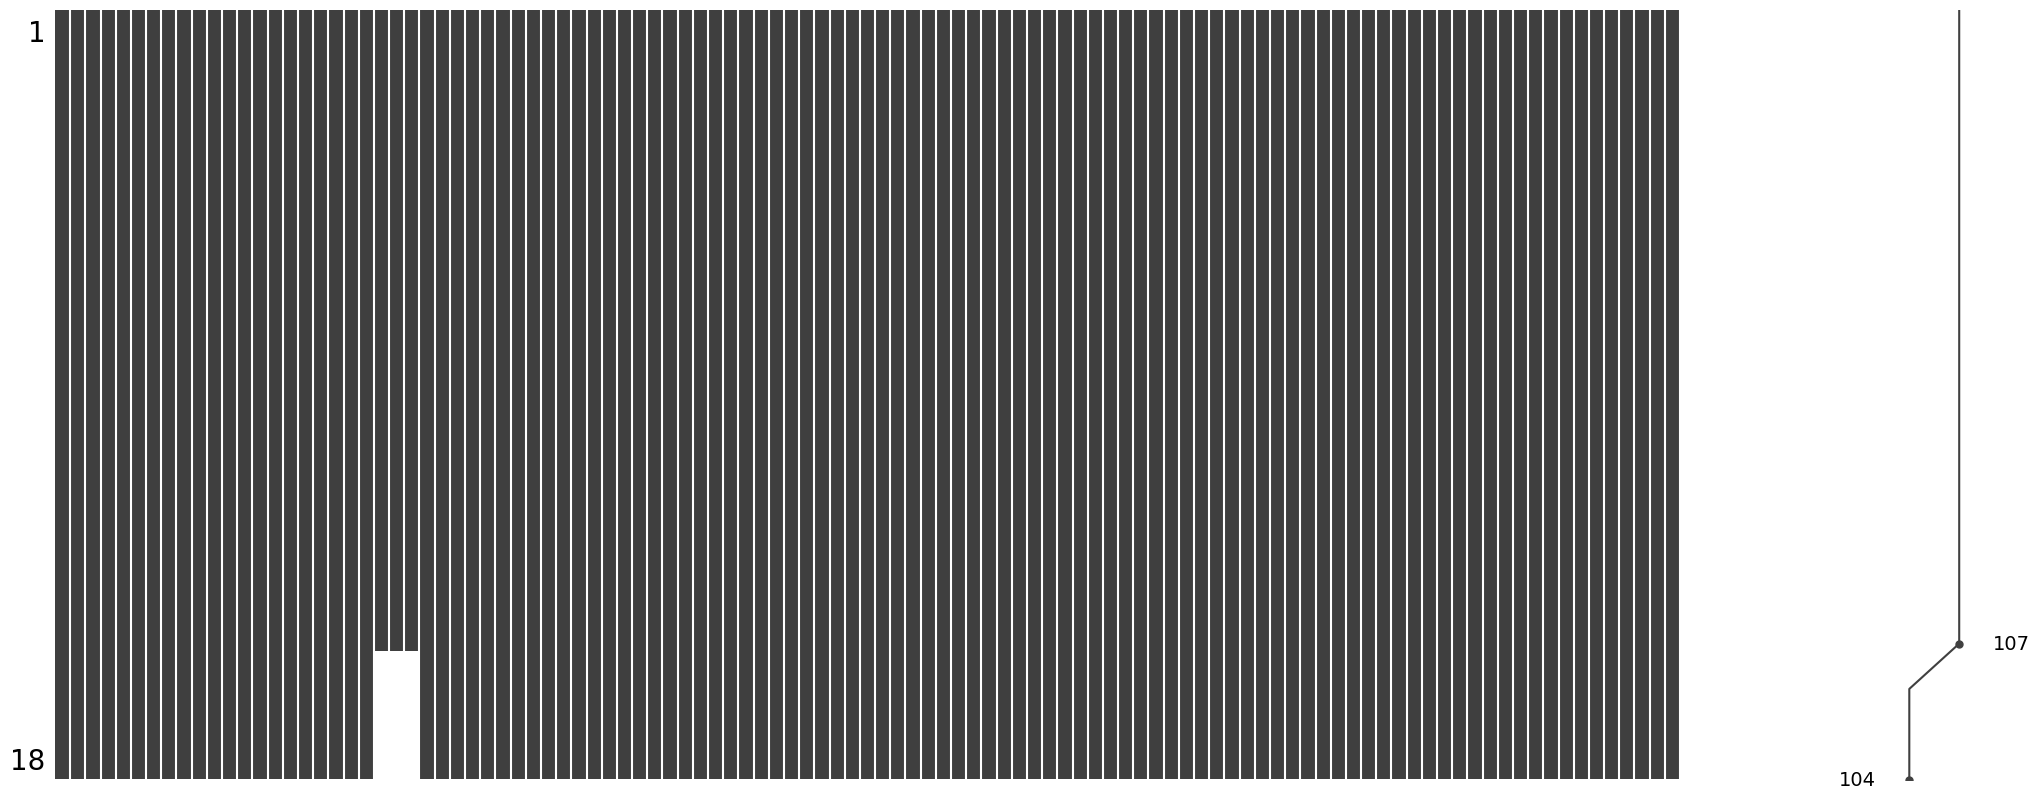

In [108]:
missingno.matrix(dataset)

In [109]:
df_economics = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Economics_Processed.csv', encoding = enc)

In [110]:
df_economics

,NUTS3_CODE,YEAR,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [111]:
df_economics.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [112]:
df_economics

,NUTS3_ID,year,MIO_EUR
0,EL301,2000,10002.340000
1,EL301,2001,10677.520000
2,EL301,2002,12022.340000
3,EL301,2003,12784.960000
4,EL301,2004,14149.980000
...,...,...,...
1139,EL653,2017,3112.330000
1140,EL653,2018,3111.760000
1141,EL653,2019,3149.580000
1142,EL653,2020,2795.860000


In [113]:
dataset = pd.merge(dataset, df_economics,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

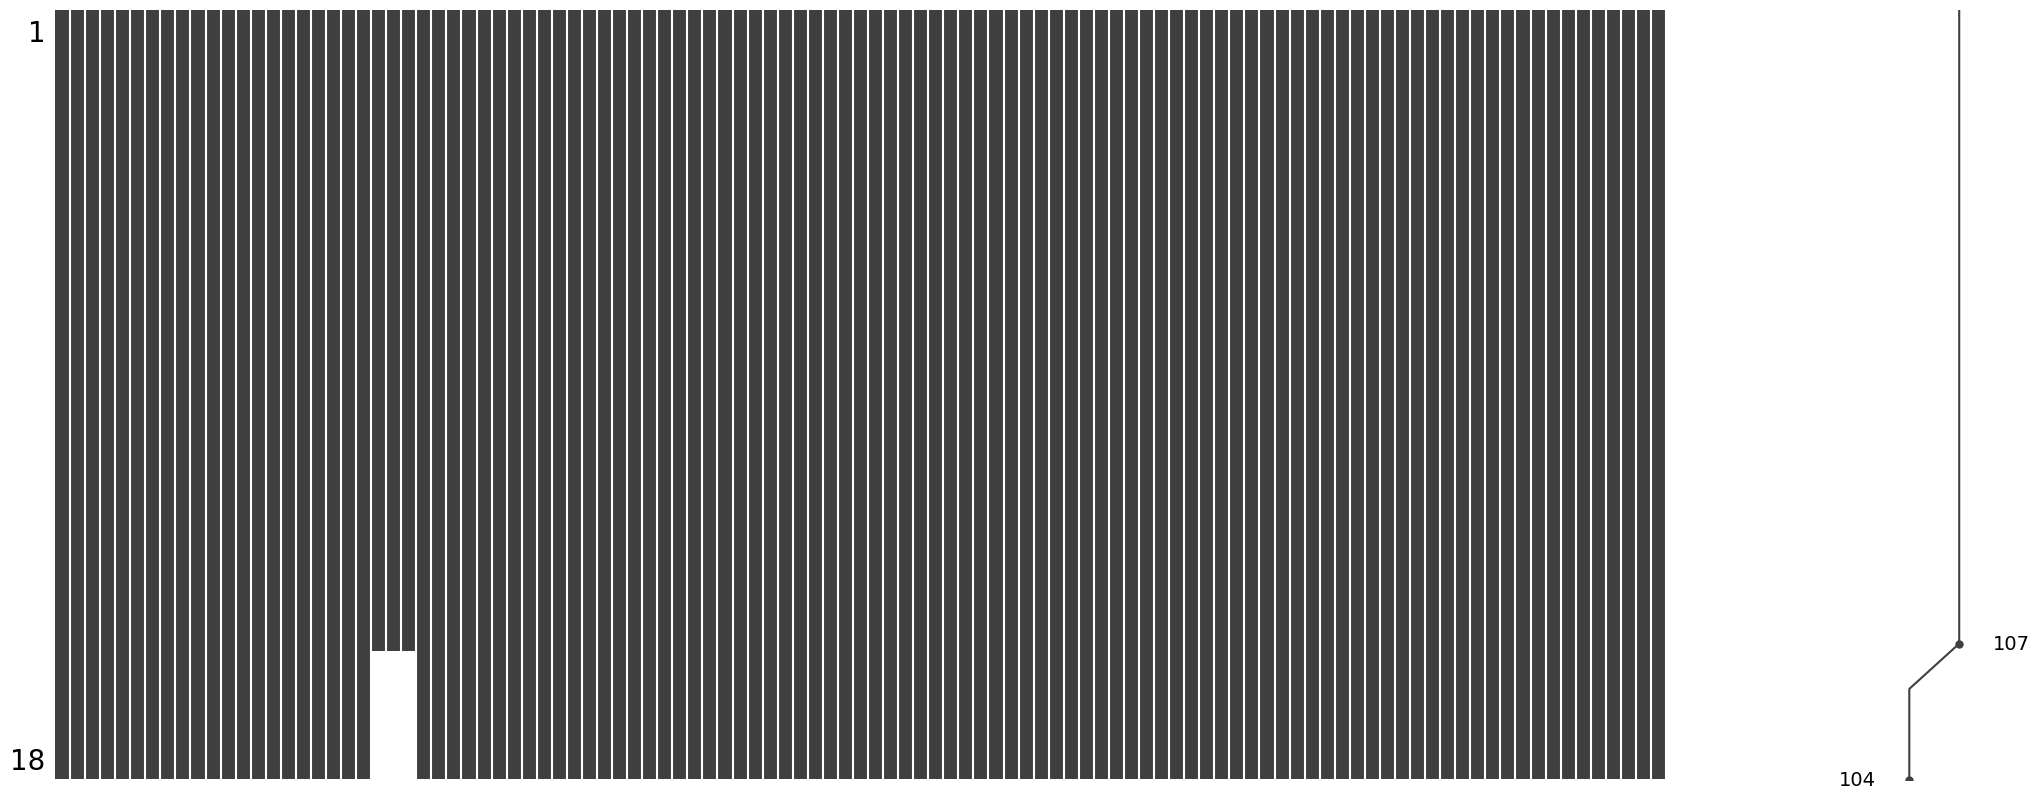

In [114]:
missingno.matrix(dataset)

In [115]:
df_trade = pd.read_csv(f'../../data/{NUTS0}_EUROSTAT_Trade_Processed.csv', encoding = enc)

In [116]:
df_trade

,NUTS3_CODE,YEAR,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [117]:
df_trade.rename(columns={'NUTS3_CODE': 'NUTS3_ID', 'YEAR': 'year'}, inplace=True)

In [118]:
df_trade

,NUTS3_ID,year,L_TOTAL,UNL_TOTAL
0,EL111,2008,6704.000000,7125.000000
1,EL111,2009,3031.000000,3303.000000
2,EL111,2010,2663.000000,2085.000000
3,EL111,2011,4163.000000,4212.000000
4,EL111,2012,4379.000000,5029.000000
...,...,...,...,...
766,EL653,2018,2358.000000,2885.000000
767,EL653,2019,2914.000000,3549.000000
768,EL653,2020,4572.000000,4962.000000
769,EL653,2021,3040.000000,3666.000000


In [119]:
dataset = pd.merge(dataset, df_trade,  how='left', on=['NUTS3_ID', 'year'])

<Axes: >

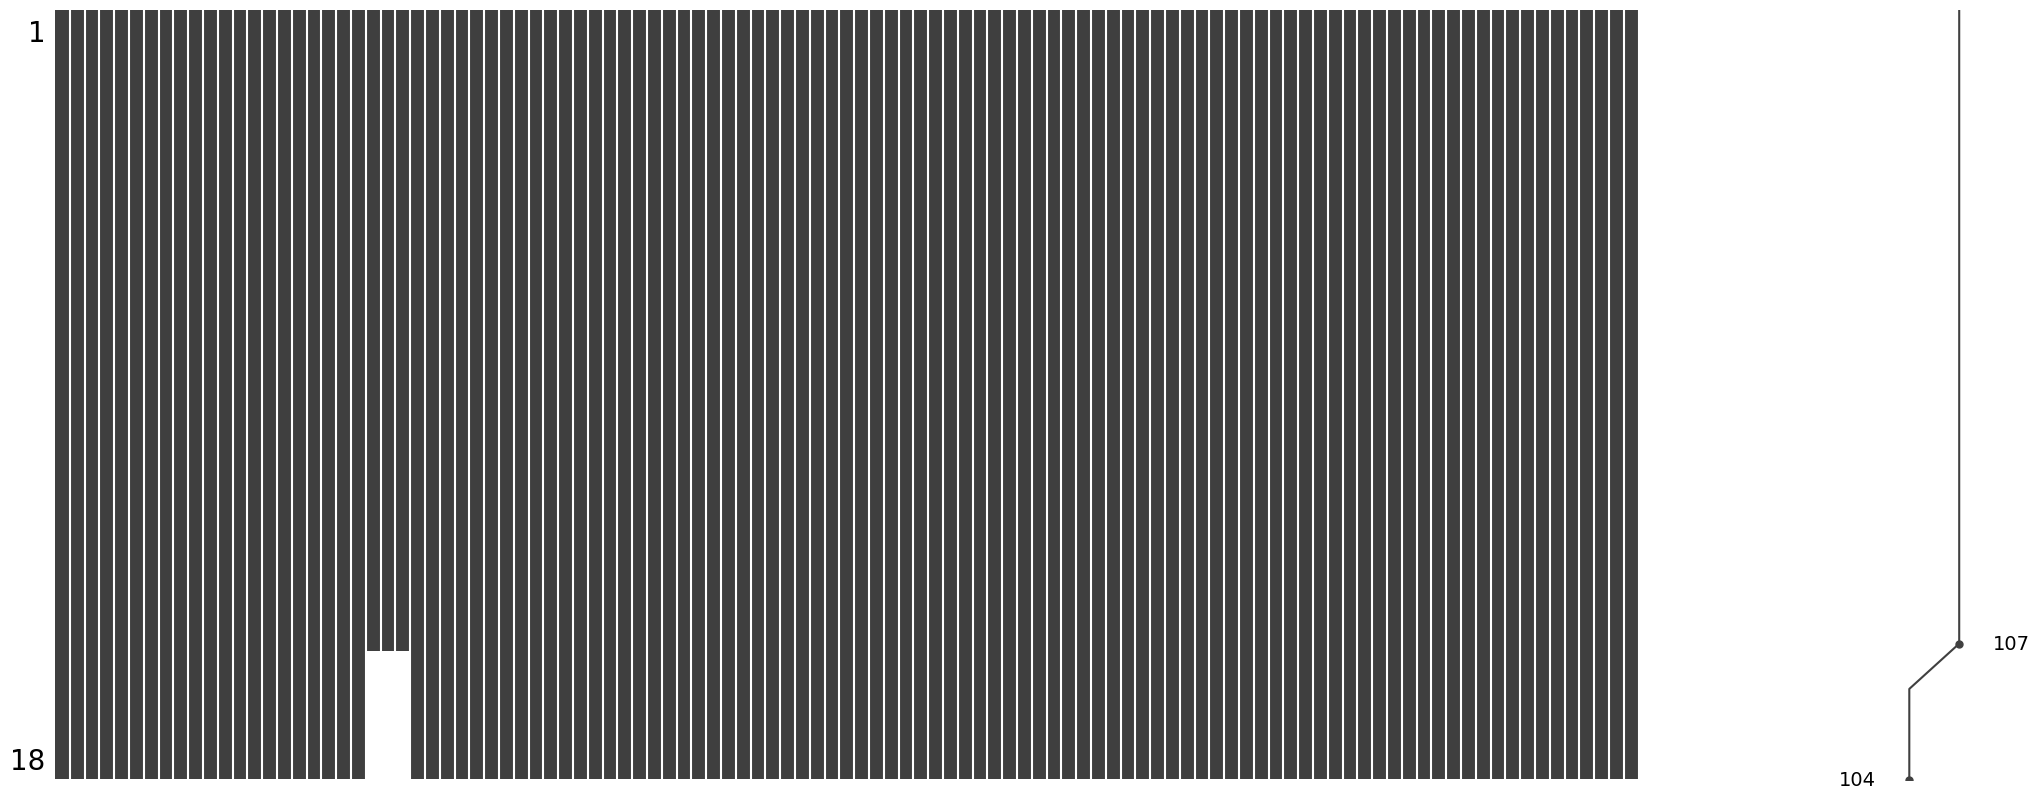

In [120]:
missingno.matrix(dataset)

In [121]:
missing = describe_dataframe(dataset)

In [122]:
missing

,Column,Missing
0,dt_placement,0.000000
1,NUTS2_ID,0.000000
2,NUTS2_NAME,0.000000
3,NUTS3_ID,0.000000
4,NUTS3_NAME,0.000000
...,...,...
113,F_Y_GE65,100.000000
114,F_TOTAL,100.000000
115,MIO_EUR,100.000000
116,L_TOTAL,100.000000


In [123]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2024,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,2.754859,5.497419,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373,0,12.750000,18.833333,60.752688,561.025846,29.000000,-2.000000,31.000000,8.166667,17.333333,17.333333,8.166667,431.000000,116.000000,0.000000,56.991259,270.000000,161.000000,161.000000,270.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,0,13.666667,21.666667,63.725490,570.672118,32.000000,-2.000000,34.000000,16.666667,10.666667,18.333333,9.000000,382.000000,94.000000,0.000000,53.000119,256.000000,126.000000,185.000000,197.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2024,0.397821,0.237224,-0.313479,-0.237224,0.400174,0.234837,-0.318410,-0.234837,0.068333,0.069368,0.065917,0.069368,10.133658,5.566575,7.850116,10.133658,12.615667,15.692800,22.897291,5.566575,6.373015,7.483881,11.991336,7.850116,9.494341,11.588341,17.444313,2.364135,4.172262,18.432752,71.336729,73.288175,87.030928,2.807449,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640

In [124]:
dataset.reset_index(inplace=True, drop=True)

In [125]:
dataset['cases'].value_counts()

cases
0    18
Name: count, dtype: int64

In [126]:
dataset['cases'].sum()

0

In [127]:
dataset

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2024-01,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.720538,39.507246,1,2024,0.334221,0.159408,-0.277486,-0.159408,0.326529,0.154023,-0.270094,-0.154214,0.068113,0.071497,0.069693,0.071539,8.239980,2.754859,5.497419,8.239980,11.270013,15.315817,23.483530,2.754859,3.885821,5.499430,10.308722,5.497419,7.577917,10.407623,16.896126,3.772496,1.491260,15.810806,116.658697,116.947373,491.493711,15.854636,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.000000,1.000000,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,31,36,30,12,12,1,6,7,2,-2.440881,13.502390,116.947373,0,12.750000,18.833333,60.752688,561.025846,29.000000,-2.000000,31.000000,8.166667,17.333333,17.333333,8.166667,431.000000,116.000000,0.000000,56.991259,270.000000,161.000000,161.000000,270.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-01,EL61,θεσσαλια,EL612,λαρισα,22.407574,39.702044,1,2024,0.411374,0.149866,-0.347088,-0.149866,0.405401,0.145257,-0.342477,-0.145257,0.065402,0.071927,0.058498,0.071927,10.064603,3.168784,6.616693,10.064603,13.185553,16.886099,24.998637,3.168784,4.355285,6.046111,10.508383,6.616693,8.770419,11.466105,17.753510,1.828530,3.117468,17.913520,55.938405,56.684445,508.763441,16.411724,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.000000,1.000000,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,31,36,30,12,12,1,6,7,2,-2.565914,16.256380,56.684445,0,13.666667,21.666667,63.725490,570.672118,32.000000,-2.000000,34.000000,16.666667,10.666667,18.333333,9.000000,382.000000,94.000000,0.000000,53.000119,256.000000,126.000000,185.000000,197.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2024-01,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.862978,39.279998,1,2024,0.397821,0.237224,-0.313479,-0.237224,0.400174,0.234837,-0.318410,-0.234837,0.068333,0.069368,0.065917,0.069368,10.133658,5.566575,7.850116,10.133658,12.615667,15.692800,22.897291,5.566575,6.373015,7.483881,11.991336,7.850116,9.494341,11.588341,17.444313,2.364135,4.172262,18.432752,71.336729,73.288175,87.030928,2.807449,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640

In [128]:
cols = dataset.columns

In [129]:
print(cols)


Index(['dt_placement', 'NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x',
       'y', 'month', 'year', 'ndvi',
       ...
       'M_Y15-64', 'M_Y_GE65', 'M_TOTAL', 'F_Y_LT15', 'F_Y15-64', 'F_Y_GE65',
       'F_TOTAL', 'MIO_EUR', 'L_TOTAL', 'UNL_TOTAL'],
      dtype='object', length=118)


In [130]:
len(cols)

118

In [131]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2024.csv", encoding = enc, index = False)
